# 02 · RFM & Clustering

RFM feature engineering, algorithm comparison (KMeans / Hierarchical / GMM), model selection, and segment labeling.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from shopper_spectrum.config import load_config
from shopper_spectrum.data.loader import load_raw
from shopper_spectrum.data.preprocessing import clean
cfg = load_config('../config/config.yaml')
df = clean(load_raw('../data/raw/online_retail.csv'), cfg['preprocessing'])
print('Clean rows:', len(df), '| Customers:', df['CustomerID'].nunique())
df.head()

Clean rows: 392688 | Customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Build RFM features (with 1-5 quartile scores)

In [2]:
from shopper_spectrum.features.rfm import build_rfm
rfm = build_rfm(df, cfg['rfm'])
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,7
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1797.24,2,4,4,10
3,12349,19,1,1757.55,4,1,4,9
4,12350,310,1,334.40,1,1,2,4


In [3]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.00000
mean,92.536422,4.272015,2048.68808
std,100.014169,7.697998,8985.23022
min,1.000000,1.000000,3.75000
25%,18.000000,1.000000,306.48250
50%,51.000000,2.000000,668.57000
75%,142.000000,5.000000,1660.59750
max,374.000000,209.000000,280206.02000


## Scale features (log-transform skewed F & M, then standardize)

In [4]:
from shopper_spectrum.models import clustering as clu
X, scaler = clu.scale_features(rfm, cfg['rfm']['log_transform'])
X.shape

(4338, 3)

## Compare clustering algorithms across k

We evaluate KMeans, Hierarchical and GMM using silhouette, Calinski-Harabasz and Davies-Bouldin.

In [5]:
metrics = clu.compare_algorithms(X, cfg['clustering']['algorithms'], range(2,11), 42)
metrics.round(3)

,algorithm,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,kmeans,2,6874.932,0.406,3871.912,0.915
1,kmeans,3,4299.067,0.416,4393.914,0.825
2,kmeans,4,3243.033,0.380,4352.685,0.860
3,kmeans,5,2760.794,0.343,4023.047,0.941
4,kmeans,6,2396.855,0.330,3837.862,0.982
5,kmeans,7,2166.959,0.301,3613.299,1.019
6,kmeans,8,1961.089,0.300,3486.408,1.001
7,kmeans,9,1819.158,0.283,3330.095,1.029
8,kmeans,10,1687.779,0.282,3227.187,1.020
9,hierarchical,2,NaN,0.397,3556.692,0.877


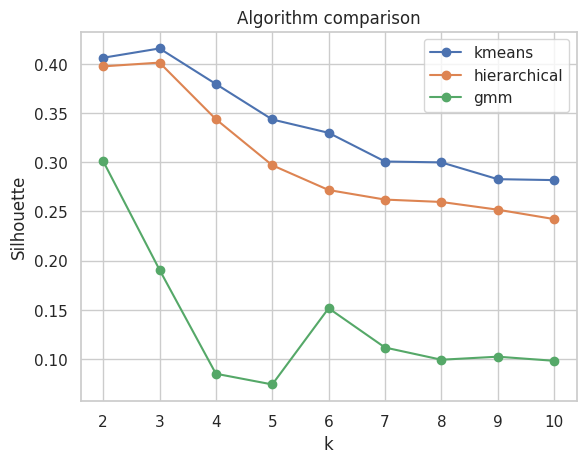

In [6]:
for algo in metrics['algorithm'].unique():
    sub = metrics[metrics['algorithm']==algo]
    plt.plot(sub['k'], sub['silhouette'], 'o-', label=algo)
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Algorithm comparison'); plt.legend(); plt.show()

## Elbow & silhouette (KMeans)

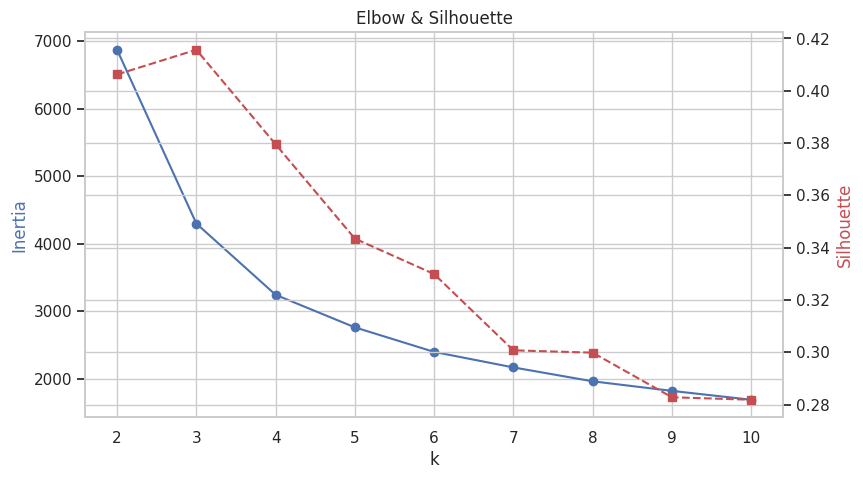

In [7]:
km = metrics[metrics['algorithm']=='kmeans']
fig, a1 = plt.subplots(figsize=(9,5))
a1.plot(km['k'], km['inertia'], 'o-', color='#4C72B0'); a1.set_ylabel('Inertia', color='#4C72B0'); a1.set_xlabel('k')
a2 = a1.twinx(); a2.plot(km['k'], km['silhouette'], 's--', color='#C44E52'); a2.set_ylabel('Silhouette', color='#C44E52')
plt.title('Elbow & Silhouette'); plt.show()

## Fit final model (k=4) and label segments

In [8]:
labels, model = clu.fit_final(X, cfg['clustering']['final_algorithm'], cfg['clustering']['chosen_k'], 42)
rfm['Cluster'] = labels
label_map = clu.label_segments(rfm, cfg['clustering']['segment_labels'])
rfm['Segment'] = rfm['Cluster'].map(label_map)
from sklearn.metrics import silhouette_score
print('Silhouette @ k=4:', round(silhouette_score(X, labels),3))
label_map

Silhouette @ k=4: 0.38


{2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}

In [9]:
prof = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
prof['Customers'] = rfm['Segment'].value_counts(); prof

,Recency,Frequency,Monetary,Customers
Segment,,,,
At-Risk,259.4,1.4,385.4,938
High-Value,19.8,15.8,9823.4,571
Occasional,58.0,1.5,384.2,1377
Regular,46.1,4.2,1644.3,1452


## Visualize segments (2D and 3D)

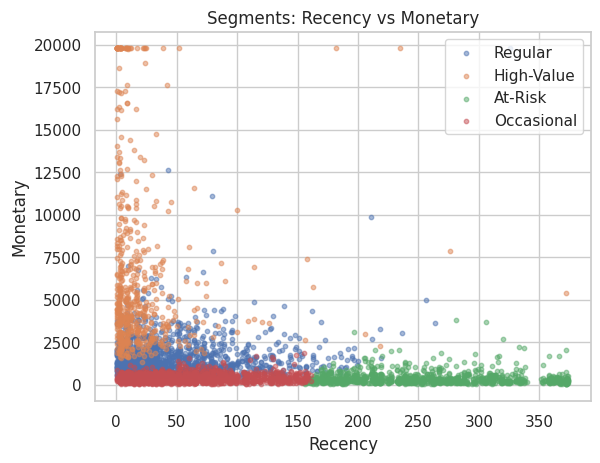

In [10]:
for seg in rfm['Segment'].unique():
    s = rfm[rfm['Segment']==seg]
    plt.scatter(s['Recency'], s['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)), s=10, alpha=0.5, label=seg)
plt.xlabel('Recency'); plt.ylabel('Monetary'); plt.legend(); plt.title('Segments: Recency vs Monetary'); plt.show()

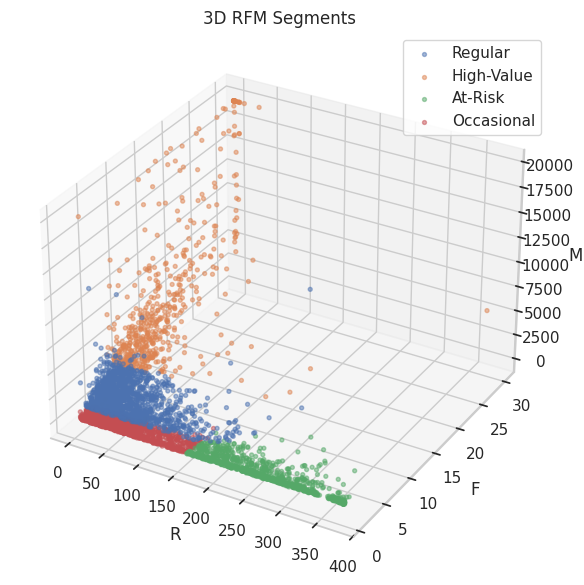

In [11]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9,7)); ax = fig.add_subplot(111, projection='3d')
for seg in rfm['Segment'].unique():
    s = rfm[rfm['Segment']==seg]
    ax.scatter(s['Recency'], s['Frequency'].clip(upper=rfm['Frequency'].quantile(.99)), s['Monetary'].clip(upper=rfm['Monetary'].quantile(.99)), s=8, alpha=.5, label=seg)
ax.set_xlabel('R'); ax.set_ylabel('F'); ax.set_zlabel('M'); ax.legend(); plt.title('3D RFM Segments'); plt.show()